In [1]:
import pandas as pd
import numpy as np
import os
from glob import glob
from scipy.stats import entropy
import matplotlib.pyplot as plt
import seaborn as sns

PROCESSED_DATA_PATH = r"C:\Users\Enjoy\OneDrive\Desktop\STData\processed"
FEATURE_DATASET_PATH = r"C:\Users\Enjoy\OneDrive\Desktop\STData\final_features.csv"

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported and paths configured.")

Libraries imported and paths configured.


In [2]:
def get_basic_stats(series):
    """Calculates basic statistics for a pandas Series."""
    return {'mean': series.mean(), 'std': series.std(), 'var': series.var(), 'min': series.min(), 'max': series.max()}

def calculate_eeg_features(df):
    """Calculates features from EEG data."""
    features = {}
    bands = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']
    for band in bands:
        band_cols = [col for col in df.columns if band in col]
        if not band_cols: continue
        band_data = df[band_cols].mean(axis=1)
        stats = get_basic_stats(band_data)
        for stat_name, value in stats.items():
            features[f'eeg_{band.lower()}_{stat_name}'] = value
        power_spectrum = np.abs(np.fft.fft(band_data))**2
        features[f'eeg_{band.lower()}_spectral_entropy'] = entropy(power_spectrum)
    if 'eeg_theta_mean' in features and 'eeg_beta_mean' in features and features['eeg_beta_mean'] != 0:
        features['eeg_theta_beta_ratio'] = features['eeg_theta_mean'] / features['eeg_beta_mean']
    return features

def calculate_eye_features(eye_df, ivt_df):
    """Calculates features from eye-tracking data."""
    features = {}
    if 'ET_PupilLeft' in eye_df.columns and 'ET_PupilRight' in eye_df.columns:
        pupil_size = eye_df[['ET_PupilLeft', 'ET_PupilRight']].mean(axis=1)
        stats = get_basic_stats(pupil_size)
        for stat_name, value in stats.items():
            features[f'eye_pupil_{stat_name}'] = value
    if 'ET_GazeLeftx' in eye_df.columns and 'ET_GazeLefty' in eye_df.columns:
        gaze_x_std, gaze_y_std = eye_df['ET_GazeLeftx'].std(), eye_df['ET_GazeLefty'].std()
        features['eye_gaze_variability'] = np.sqrt(gaze_x_std**2 + gaze_y_std**2)
    if 'Fixation Duration' in ivt_df.columns:
        features['eye_avg_fixation_duration'] = ivt_df['Fixation Duration'].mean()
        features['eye_fixation_count'] = ivt_df['Fixation Duration'].count()
    if 'Saccade Amplitude' in ivt_df.columns:
        features['eye_avg_saccade_amplitude'] = ivt_df['Saccade Amplitude'].mean()
    if 'ET_PupilLeft' in eye_df.columns:
        features['eye_blink_count'] = (eye_df['ET_PupilLeft'] <= 0).sum()
    return features

print("Feature extraction functions defined.")

Feature extraction functions defined.


In [3]:
all_trials_features = []
eeg_files = glob(os.path.join(PROCESSED_DATA_PATH, "*", "*_eeg.csv"))

print(f"Found a total of {len(eeg_files)} trials to process.")
print("\nFirst 5 trial files found:")
for f in eeg_files[:5]:
    print(f"  - {os.path.basename(f)}")

Found a total of 1527 trials to process.

First 5 trial files found:
  - student_1_trial_0_eeg.csv
  - student_1_trial_10_eeg.csv
  - student_1_trial_11_eeg.csv
  - student_1_trial_12_eeg.csv
  - student_1_trial_13_eeg.csv


In [4]:
sample_eeg_file = eeg_files[0]
trial_id = os.path.basename(sample_eeg_file).replace("_eeg.csv", "")

print(f"--- Loading Sample Trial: {trial_id} ---")

try:
    eeg_df_sample = pd.read_csv(sample_eeg_file)
    eye_df_sample = pd.read_csv(sample_eeg_file.replace("_eeg.csv", "_eye.csv"))
    ivt_df_sample = pd.read_csv(sample_eeg_file.replace("_eeg.csv", "_ivt.csv"))

    print("\nEEG Data Head:")
    display(eeg_df_sample.head(3))
    
    print("\nEye-Tracking Data Head:")
    display(eye_df_sample.head(3))
    
except FileNotFoundError:
    print(f"Could not load all files for sample trial {trial_id}")

--- Loading Sample Trial: student_1_trial_0 ---

EEG Data Head:


,TimeStamp,UnixTime,QuestionKey,Delta_TP9,Delta_AF7,Delta_AF8,Delta_TP10,Theta_TP9,Theta_AF7,Theta_AF8,...,Gyro_X,Gyro_Y,Gyro_Z,HeadBandOn,HSI_TP9,HSI_AF7,HSI_AF8,HSI_TP10,Battery,Elements
0,2023-03-28 17:04:09.790,1.680003e+09,1spl1,0.267794,0.157727,0.588505,0.784742,0.351401,-0.231382,0.178665,...,-0.433655,2.743988,4.149628,1.0,1.0,1.0,1.0,1.0,92.89,NaN
1,2023-03-28 17:04:09.792,1.680003e+09,1spl1,0.267794,0.157727,0.588505,0.784742,0.351401,-0.231382,0.178665,...,-0.433655,2.743988,4.149628,1.0,1.0,1.0,1.0,1.0,92.89,NaN
2,2023-03-28 17:04:09.794,1.680003e+09,1spl1,0.267794,0.157727,0.588505,0.784742,0.351401,-0.231382,0.178665,...,-0.433655,2.743988,4.149628,1.0,1.0,1.0,1.0,1.0,92.89,NaN



Eye-Tracking Data Head:


,UnixTime,Row,QuestionKey,Timestamp,ET_GazeLeftx,ET_GazeLefty,ET_GazeRightx,ET_GazeRighty,ET_PupilLeft,ET_PupilRight,ET_TimeSignal,ET_DistanceLeft,ET_DistanceRight,ET_CameraLeftX,ET_CameraLeftY,ET_CameraRightX,ET_CameraRightY,ET_ValidityLeft,ET_ValidityRight
0,1.680003e+09,12575,1spl1,2023-03-28 17:04:09.790904,928.0,539.0,914.0,550.0,-1.000000,-1.000000,104799.253,583.498901,579.684082,0.586616,0.490012,0.426641,0.489471,0.0,0.0
1,1.680003e+09,12576,1spl1,2023-03-28 17:04:09.799212,919.0,548.0,916.0,549.0,-1.000000,-1.000000,104807.563,583.273499,579.813477,0.586718,0.489877,0.426725,0.489385,0.0,0.0
2,1.680003e+09,12577,1spl1,2023-03-28 17:04:09.807787,918.0,549.0,923.0,548.0,2.979706,2.958359,104816.135,583.058960,579.947937,0.586697,0.489982,0.426639,0.489381,0.0,0.0


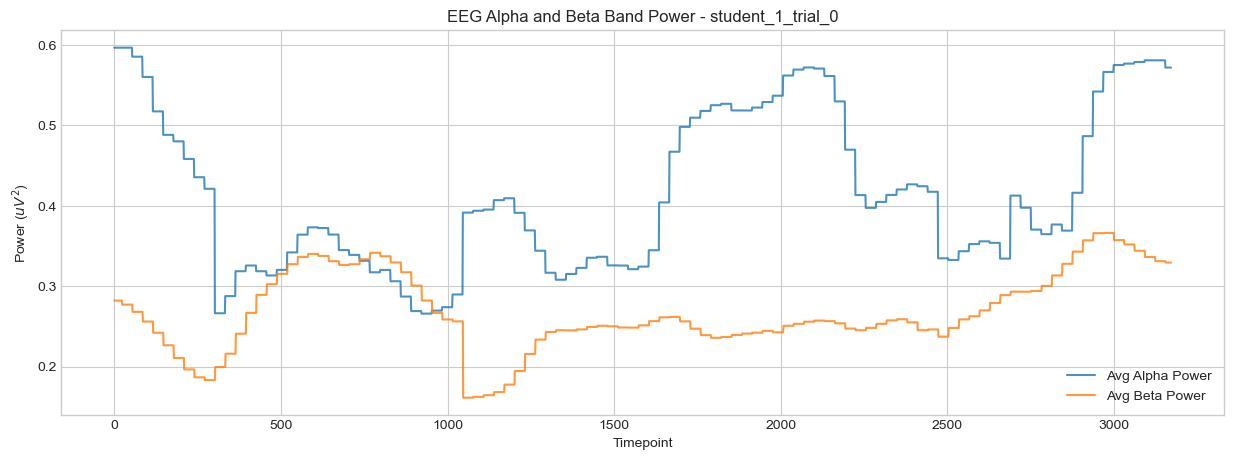

In [5]:
plt.figure(figsize=(15, 5))
plt.title(f'EEG Alpha and Beta Band Power - {trial_id}')
plt.plot(eeg_df_sample.index, eeg_df_sample[[c for c in eeg_df_sample.columns if 'Alpha' in c]].mean(axis=1), label='Avg Alpha Power', alpha=0.8)
plt.plot(eeg_df_sample.index, eeg_df_sample[[c for c in eeg_df_sample.columns if 'Beta' in c]].mean(axis=1), label='Avg Beta Power', alpha=0.8)
plt.xlabel("Timepoint")
plt.ylabel("Power ($uV^2$)")
plt.legend()
plt.show()

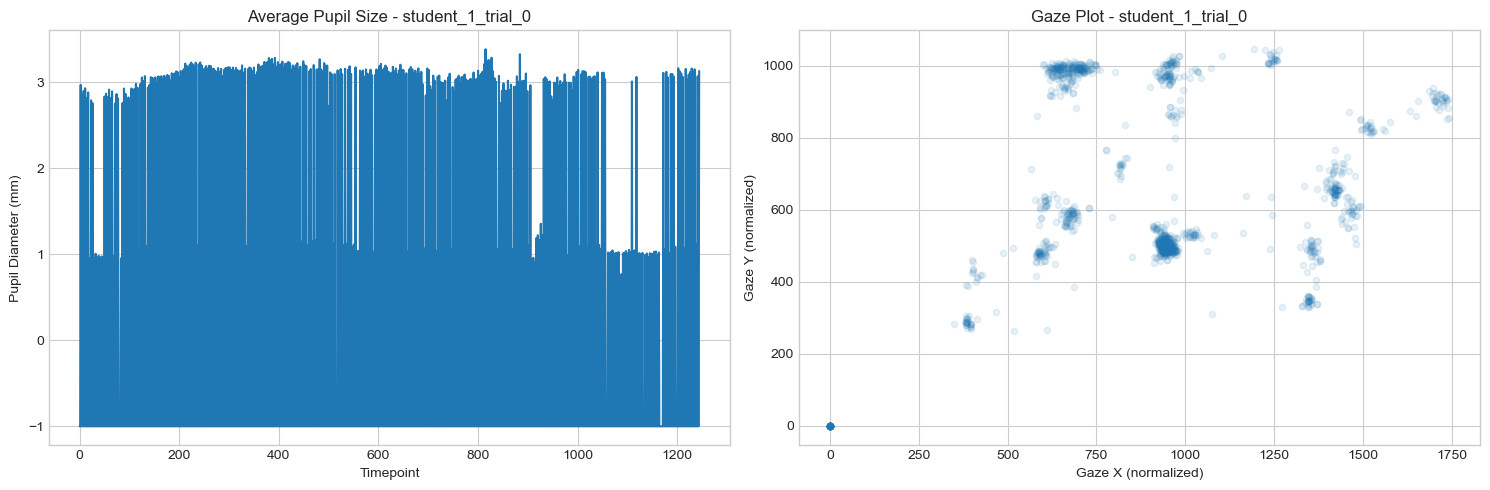

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Pupil Size
pupil_size = eye_df_sample[['ET_PupilLeft', 'ET_PupilRight']].mean(axis=1)
pupil_size.plot(ax=ax[0], title=f'Average Pupil Size - {trial_id}')
ax[0].set_xlabel("Timepoint")
ax[0].set_ylabel("Pupil Diameter (mm)")

# Gaze Plot
eye_df_sample.plot.scatter(x='ET_GazeLeftx', y='ET_GazeLefty', alpha=0.1, ax=ax[1], title=f'Gaze Plot - {trial_id}')
ax[1].set_xlabel("Gaze X (normalized)")
ax[1].set_ylabel("Gaze Y (normalized)")
plt.tight_layout()
plt.show()

In [7]:
print(f"--- Calculated Features for Sample: {trial_id} ---")

eeg_features_sample = calculate_eeg_features(eeg_df_sample)
eye_features_sample = calculate_eye_features(eye_df_sample, ivt_df_sample)

print("\nEEG Features:")
for key, val in eeg_features_sample.items():
    print(f"  - {key}: {val:.4f}")

print("\nEye-Tracking Features:")
for key, val in eye_features_sample.items():
    print(f"  - {key}: {val:.4f}")

--- Calculated Features for Sample: student_1_trial_0 ---

EEG Features:
  - eeg_delta_mean: 0.2395
  - eeg_delta_std: 0.1469
  - eeg_delta_var: 0.0216
  - eeg_delta_min: -0.0201
  - eeg_delta_max: 0.5679
  - eeg_delta_spectral_entropy: 1.1724
  - eeg_theta_mean: 0.1766
  - eeg_theta_std: 0.0714
  - eeg_theta_var: 0.0051
  - eeg_theta_min: -0.0087
  - eeg_theta_max: 0.3664
  - eeg_theta_spectral_entropy: 0.7733
  - eeg_alpha_mean: 0.4145
  - eeg_alpha_std: 0.0977
  - eeg_alpha_var: 0.0095
  - eeg_alpha_min: 0.2659
  - eeg_alpha_max: 0.5967
  - eeg_alpha_spectral_entropy: 0.3386
  - eeg_beta_mean: 0.2677
  - eeg_beta_std: 0.0484
  - eeg_beta_var: 0.0023
  - eeg_beta_min: 0.1614
  - eeg_beta_max: 0.3663
  - eeg_beta_spectral_entropy: 0.2133
  - eeg_gamma_mean: -0.2078
  - eeg_gamma_std: 0.0483
  - eeg_gamma_var: 0.0023
  - eeg_gamma_min: -0.3302
  - eeg_gamma_max: -0.1324
  - eeg_gamma_spectral_entropy: 0.3271
  - eeg_theta_beta_ratio: 0.6596

Eye-Tracking Features:
  - eye_pupil_mean: 0

In [8]:
print("Starting feature extraction for all trials...")
for i, eeg_file_path in enumerate(eeg_files):
    trial_id = os.path.basename(eeg_file_path).replace("_eeg.csv", "")
    try:
        eeg_df = pd.read_csv(eeg_file_path)
        eye_df = pd.read_csv(eeg_file_path.replace("_eeg.csv", "_eye.csv"))
        ivt_df = pd.read_csv(eeg_file_path.replace("_eeg.csv", "_ivt.csv"))
        meta_df = pd.read_csv(eeg_file_path.replace("_eeg.csv", "_meta.csv"))
        
        eeg_features = calculate_eeg_features(eeg_df)
        eye_features = calculate_eye_features(eye_df, ivt_df)

        combined_features = {'trial_id': trial_id, 'response_time': meta_df['ResponseTime'].iloc[0]}
        combined_features.update(eeg_features)
        combined_features.update(eye_features)
        all_trials_features.append(combined_features)
    except FileNotFoundError:
        print(f"  -> Skipping {trial_id} due to missing data files.")
        continue

print(f"\nProcessing complete. Extracted features for {len(all_trials_features)} trials.")

Starting feature extraction for all trials...


C:\Users\Enjoy\AppData\Local\Temp\ipykernel_10180\3434063180.py:5: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  eeg_df = pd.read_csv(eeg_file_path)
C:\Users\Enjoy\AppData\Local\Temp\ipykernel_10180\3434063180.py:5: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  eeg_df = pd.read_csv(eeg_file_path)
C:\Users\Enjoy\AppData\Local\Temp\ipykernel_10180\3821494219.py:19: RuntimeWarning: invalid value encountered in scalar divide
  features['eeg_theta_beta_ratio'] = features['eeg_theta_mean'] / features['eeg_beta_mean']
C:\Users\Enjoy\AppData\Local\Temp\ipykernel_10180\3434063180.py:5: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  eeg_df = pd.read_csv(eeg_file_path)
C:\Users\Enjoy\AppData\Local\Temp\ipykernel_10180\3434063180.py:5: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=Fa


Processing complete. Extracted features for 1527 trials.


In [9]:
feature_df = pd.DataFrame(all_trials_features)

print("Shape of the raw feature DataFrame:", feature_df.shape)
print("\nFirst 5 rows of the generated DataFrame:")
display(feature_df.head())

Shape of the raw feature DataFrame: (1527, 43)

First 5 rows of the generated DataFrame:


,trial_id,response_time,eeg_delta_mean,eeg_delta_std,eeg_delta_var,eeg_delta_min,eeg_delta_max,eeg_delta_spectral_entropy,eeg_theta_mean,eeg_theta_std,...,eye_pupil_mean,eye_pupil_std,eye_pupil_var,eye_pupil_min,eye_pupil_max,eye_gaze_variability,eye_avg_fixation_duration,eye_fixation_count,eye_avg_saccade_amplitude,eye_blink_count
0,student_1_trial_0,10.369816,0.239537,0.146903,0.021580,-0.020135,0.567931,1.172398,0.176614,0.071372,...,0.190284,1.777635,3.159986,-1.0,3.382889,439.711293,1358.819046,1097,7.773025,882
1,student_1_trial_10,9.659429,0.878957,0.181840,0.033066,0.104589,1.174160,0.309628,0.717378,0.205096,...,0.112260,1.705860,2.909959,-1.0,3.629654,498.161723,345.905025,980,7.329646,847
2,student_1_trial_11,21.042414,0.931256,0.184803,0.034152,0.577722,1.333250,0.255953,0.616433,0.178468,...,0.108177,1.715587,2.943238,-1.0,3.520447,543.885934,322.570735,2005,8.103427,1803
3,student_1_trial_12,6.252160,0.350807,0.096269,0.009268,0.164777,0.475770,0.385995,0.130774,0.068989,...,0.036304,1.640583,2.691511,-1.0,3.485512,537.724470,253.741274,590,6.617334,558
4,student_1_trial_13,7.533956,0.856298,0.199314,0.039726,0.452667,1.067846,0.319499,0.405921,0.243591,...,0.204319,1.807572,3.267316,-1.0,3.480156,549.312576,260.036277,722,7.980705,648


Count of missing values per feature:
eeg_theta_spectral_entropy    1266
eeg_beta_spectral_entropy     1266
eeg_gamma_spectral_entropy    1266
eeg_delta_spectral_entropy    1266
eeg_alpha_spectral_entropy    1266
eye_avg_fixation_duration      173
eye_avg_saccade_amplitude      135
eeg_gamma_std                    1
eeg_beta_var                     1
eeg_theta_beta_ratio             1
eeg_alpha_var                    1
eeg_alpha_std                    1
eeg_beta_std                     1
eeg_theta_var                    1
eeg_theta_std                    1
eeg_delta_var                    1
eeg_delta_std                    1
eeg_gamma_var                    1
eye_pupil_min                    0
eye_pupil_var                    0
eye_pupil_max                    0
eye_pupil_std                    0
eye_pupil_mean                   0
eye_gaze_variability             0
eye_fixation_count               0
eeg_gamma_max                    0
eeg_gamma_min                    0
trial_id          

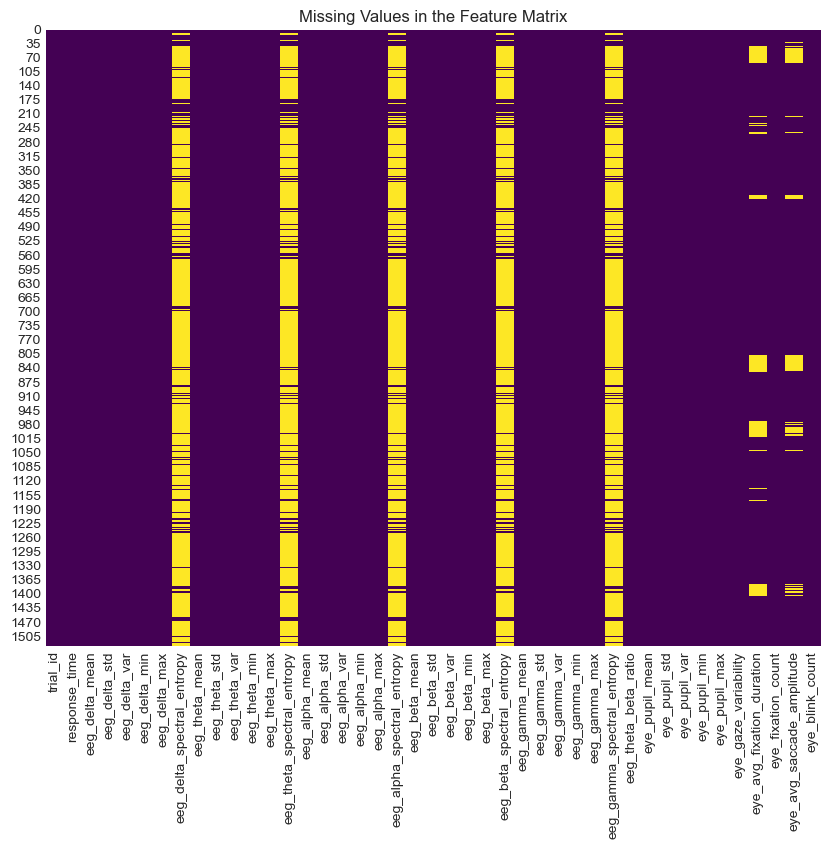

In [10]:
print("Count of missing values per feature:")
print(feature_df.isnull().sum().sort_values(ascending=False))

# --- Visualize Missing Data ---
plt.figure(figsize=(10, 8))
sns.heatmap(feature_df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values in the Feature Matrix')
plt.show()

In [11]:
rows_before = feature_df.shape[0]
feature_df.dropna(inplace=True)
rows_after = feature_df.shape[0]

print(f"Dropped {rows_before - rows_after} rows with missing values.")
print("Shape of the final cleaned DataFrame:", feature_df.shape)

Dropped 1292 rows with missing values.
Shape of the final cleaned DataFrame: (235, 43)


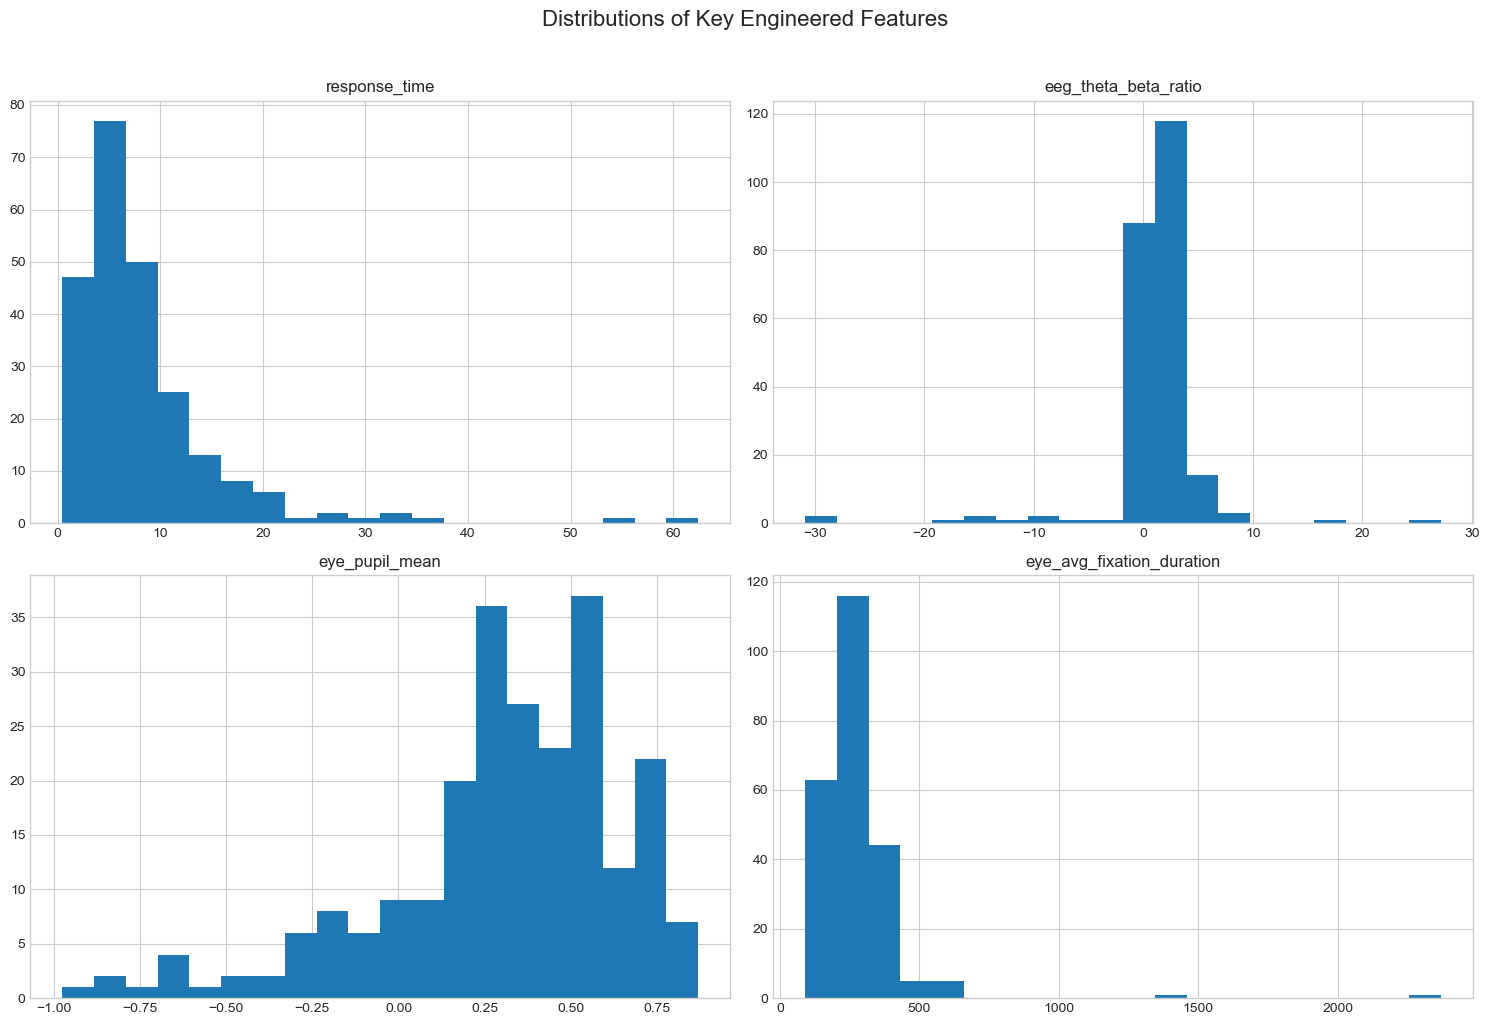

In [12]:
features_to_plot = ['response_time', 'eeg_theta_beta_ratio', 'eye_pupil_mean', 'eye_avg_fixation_duration']
feature_df[features_to_plot].hist(bins=20, figsize=(15, 10), layout=(2, 2))
plt.suptitle('Distributions of Key Engineered Features', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

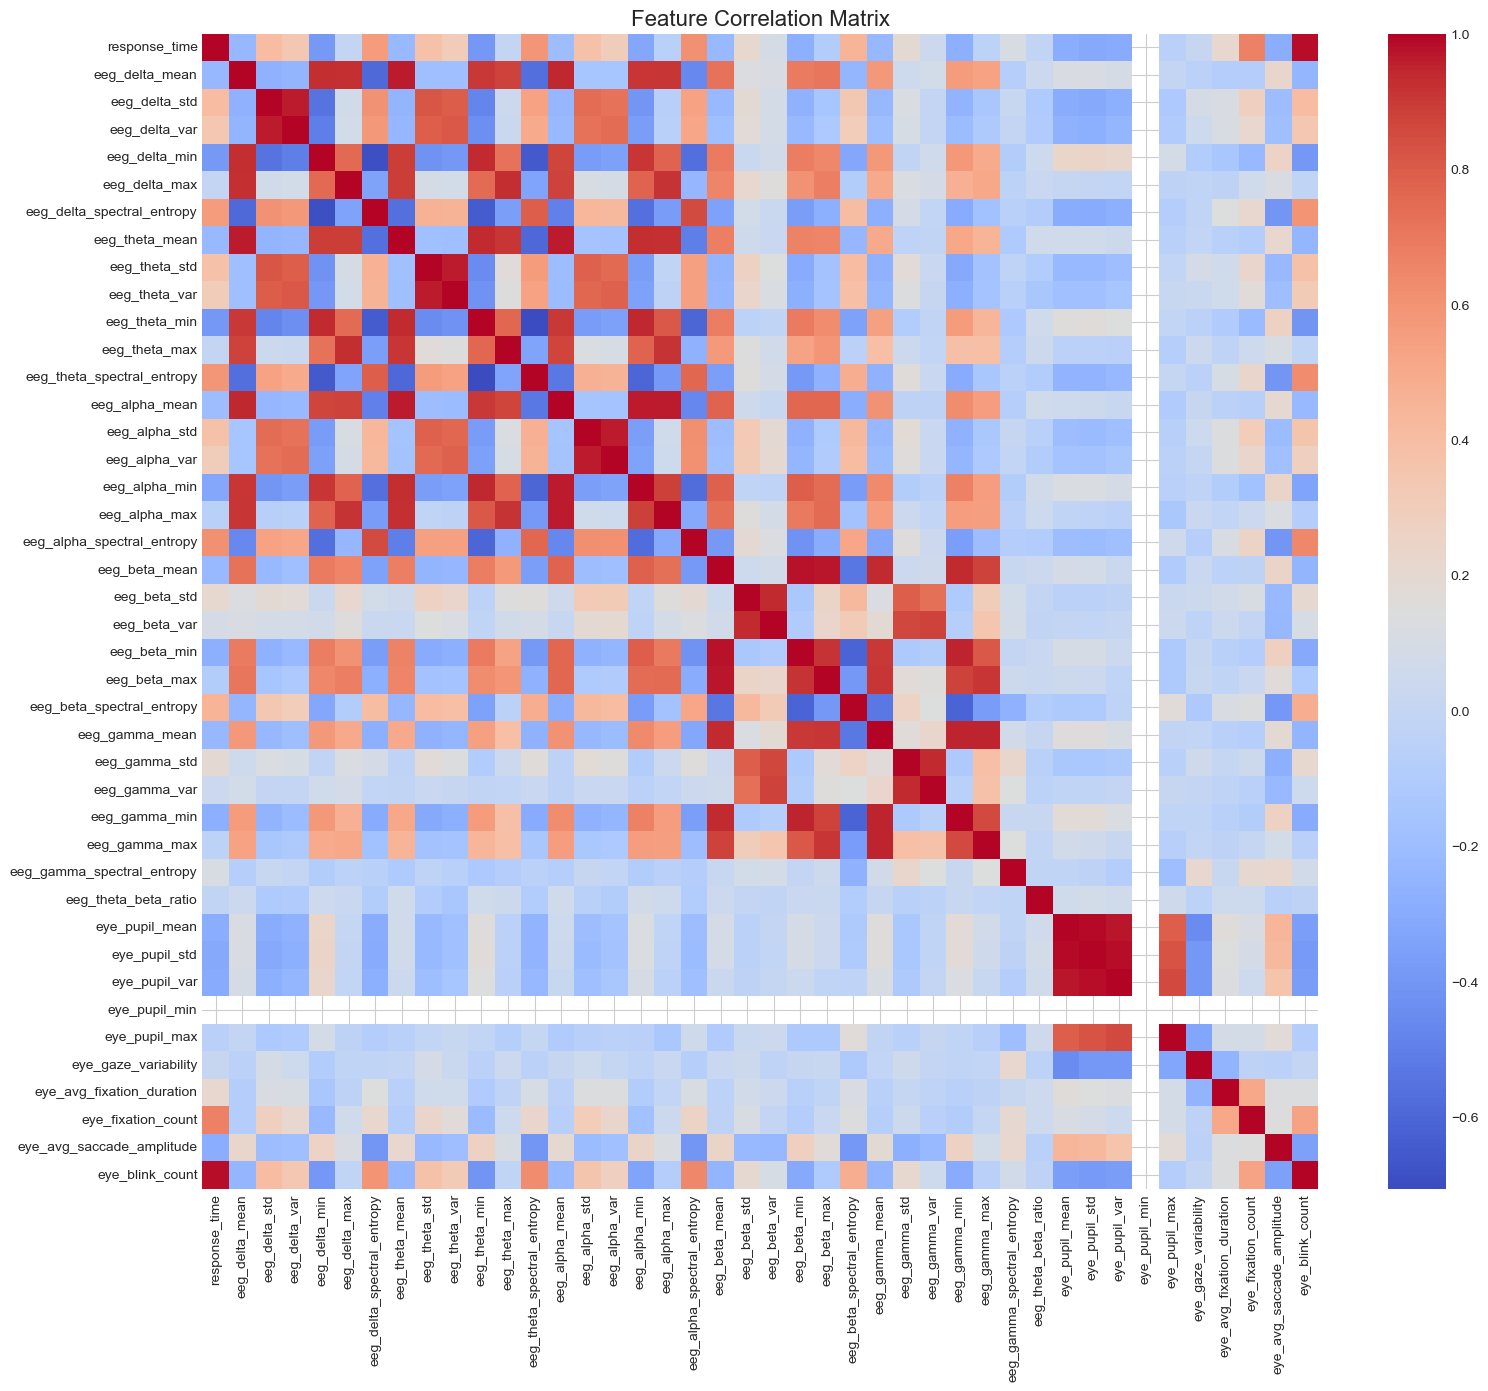

In [13]:
plt.figure(figsize=(18, 15))
corr_matrix = feature_df.drop(columns=['trial_id']).corr()
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title('Feature Correlation Matrix', fontsize=16)
plt.show()

In [14]:
feature_df.to_csv(FEATURE_DATASET_PATH, index=False)

print(f"Feature engineering complete!")
print(f"Dataset with {feature_df.shape[0]} samples and {feature_df.shape[1]} features saved to:")
print(f"{FEATURE_DATASET_PATH}")

Feature engineering complete!
Dataset with 235 samples and 43 features saved to:
C:\Users\Enjoy\OneDrive\Desktop\STData\final_features.csv
